_CASAのイメージングと、自作のイメージングを比較するために、simobserveで簡単なテストを行う_

## Simulate visibility

In [1]:
import os, sys
import numpy as np
from astropy.constants import c
from astropy import units as u
from collections import defaultdict
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from cmcrameri import cm

from astropy.io import fits
from astropy.wcs import WCS

from casatasks import listobs, mstransform, statwt, simobserve, tclean, exportfits, delmod, ft
from casatools import ms, table, componentlist, measures

sys.path.append('/home/tsujtaak/atsujita/HATLASJ0900/kinematics/delens')
import calc_lensing as cl

%matplotlib inline

In [2]:
# plt.style.use('default')
# plt.style.use(['science', 'nature'])  # Other options: 'grid', 'ieee' (readable when printed in black and white), 'nature' (sans-serif fonts), 'scatter', 'notebook'. Note that this option take longer time to produce plots.
# plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = 'Times New Roman'
# For ADC
plt.rcParams['pdf.fonttype'] = 42  # To embed fonts when saving as pdf
plt.rcParams['font.family'] = 'Liberation Serif'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['text.usetex'] = False  # Enable to use some special symbol in Italic font (e.g., theta)
plt.rcParams['font.size'] = 14  # This parameter control all text size, including title, x-axis and y-axis label, the x-axis and y-axis tick, legend, text, and annotation (default=10). We can change the font size for each element (e.g., title) using another code as followed.
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.direction'] = 'in'  # Change x-axis and y-axis tick direction (in/out/inout)
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 5.0  # Adjust major and minor tick size
plt.rcParams['xtick.minor.size'] = 3.0  # Default is 3.5 and 2.0
plt.rcParams['ytick.major.size'] = 5.0
plt.rcParams['ytick.minor.size'] = 3.0
plt.rcParams['axes.linewidth'] = 2.  # Adjust the line width of the axes (default is 0.8)
plt.rcParams['legend.handlelength'] = 0.8  # Adjust handle length
# plt.rcParams['legend.fancybox'] = False # 丸角
plt.rcParams['legend.framealpha'] = 0 # 透明度の指定、0で塗りつぶしなし
# plt.rcParams['legend.edgecolor'] = 'black' # edgeの色を変更
plt.rcParams['xtick.top'] = True            # 上部に目盛り線を描くかどうか
plt.rcParams['xtick.bottom'] = True         # 下部に目盛り線を描くかどうか
plt.rcParams['ytick.left'] = True           # 左部に目盛り線を描くかどうか
plt.rcParams['ytick.right'] = True          # 右部に目盛り線を描くかどうか
##### If need #####
# ax.xaxis.set_minor_locator(MultipleLocator(.5))  # To show the minor tick
# ax.yaxis.set_minor_locator(MultipleLocator(.5))
# plt.savefig('xxx.png', dpi = 300, pad_inches = .1, bbox_inches = 'tight')

##### For colorblind-friendly colormap #####
# One of the safest solutions you can use to deal with color blind is to avoid using red and green together.
# https://towardsdatascience.com/matplotlib-styles-for-scientific-plotting-d023f74515b4


### 適当な輝度分布を仮定

In [3]:
# 画像サイズとピクセルスケール
nx_img = ny_img = 200
pixsize_img = 0.02
x0_img, y0_img = 0.0, 0.0
xx_img, yy_img = cl.make_grid_arcsec(nx=nx_img, ny=ny_img, pixscale_arcsec=pixsize_img, x0_arcsec=x0_img, y0_arcsec=y0_img)


# まず、u,vの向きを調べるために、右上に点源を置いて、得られるvisibilityをチェックする
I0 = 1.0                        # Jy/beam ではなく Jy/pixel として扱う
# sky = np.zeros((ny_img, nx_img))
# x0 = 0.
# y0 = 0.4
# sky[ny_img//2 + int(y0/pixsize_img), nx_img//2 + int(x0/pixsize_img)] = I0

# 真のスカイ（Jy/pixel）：正規化ガウス（半値全幅 ~0.4″）
# test1：円形ガウス
# sigma_as = 0.2               # arcsec
# sky = I0 * np.exp(-(xx_img**2 + yy_img**2)/(2*sigma_as**2))

# test2：楕円ガウス
# sigma_x, sigma_y = 0.2, 0.1
# theta = np.deg2rad(30)
# xx_rot = xx_img * np.cos(theta) + yy_img * np.sin(theta)
# yy_rot = -xx_img * np.sin(theta) + yy_img * np.cos(theta)
# sky = I0 * np.exp(-(xx_rot**2/(2*sigma_x**2) + yy_rot**2/(2*sigma_y**2)))

# test3: 視野の右上に楕円ガウス
sigma_x, sigma_y = 0.2, 0.1
theta = np.deg2rad(30)
xx_rot =  (xx_img - 0.3) * np.cos(theta) + (yy_img - 0.3) * np.sin(theta)
yy_rot = -(xx_img - 0.3) * np.sin(theta) + (yy_img - 0.3) * np.cos(theta)
sky = I0 * np.exp(-(xx_rot**2/(2*sigma_x**2) + yy_rot**2/(2*sigma_y**2)))


# WCS（TAN、CDELT は arcsec→deg）
w = WCS(naxis=2)
h = w.to_header()
h['BUNIT'] = 'Jy/pixel'         # 重要：simobserve は Jy/pixel を想定

fits.writeto('sky_gauss.fits', sky.astype('float32'), h, overwrite=True)
print('Wrote sky_gauss.fits')

Wrote sky_gauss.fits


In [4]:
h

WCSAXES =                    2 / Number of coordinate axes                      
CRPIX1  =                  0.0 / Pixel coordinate of reference point            
CRPIX2  =                  0.0 / Pixel coordinate of reference point            
CDELT1  =                  1.0 / Coordinate increment at reference point        
CDELT2  =                  1.0 / Coordinate increment at reference point        
CRVAL1  =                  0.0 / Coordinate value at reference point            
CRVAL2  =                  0.0 / Coordinate value at reference point            
LATPOLE =                 90.0 / [deg] Native latitude of celestial pole        
MJDREF  =                  0.0 / [d] MJD of fiducial time                       
BUNIT   = 'Jy/pixel'                                                            

In [5]:
# # test4
# obsfits   = "../../data/B6_concat_cont_rob-0.5_clean.image.pbcor.cutout.fits"
# sky, obsheader = fits.getdata(obsfits, header=True)
# w = WCS(naxis=2)
# h = w.to_header()
# fits.writeto('sky_gauss.fits', sky.astype('float32'), h, overwrite=True)


# ny_img, nx_img = sky.shape
# pixsize_img = np.abs(obsheader['CDELT1'] * 3600.)
# print('Image size:', nx_img, 'x', ny_img)
# print('Image pixel scale:', pixsize_img, 'arcsec')
# x0_img, y0_img = 0.0, 0.0
# xx_img, yy_img = cl.make_grid_arcsec(nx=nx_img, ny=ny_img, pixscale_arcsec=pixsize_img, x0_arcsec=x0_img, y0_arcsec=y0_img)


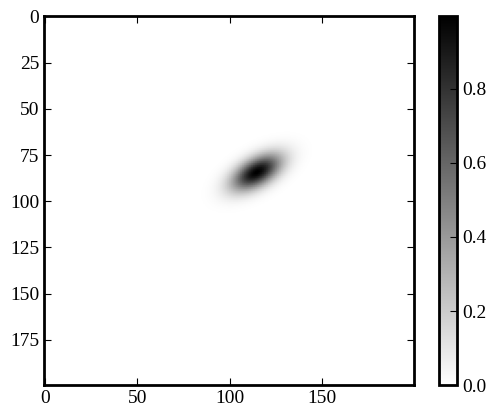

In [6]:
sky = fits.getdata('sky_gauss.fits')
plt.imshow(sky, cmap='gray_r', vmin=0)
plt.colorbar()
plt.show()

### simobserve

2026-07-20 15:08:30	WARN	simutil::CTPatchedInterp::interpolate	In caltable sim_imaging.alma.cycle7.8.noisy.T.cal_sim_temp (Tf Jones):
2026-07-20 15:08:30	WARN	simutil::CTPatchedInterp::interpolate+	 Insufficient solution channel sampling (nchan=1) for frequency-dependent LINEAR interpolation 
2026-07-20 15:08:30	WARN	simutil::CTPatchedInterp::interpolate+	 of calibration for MS spw=0; using NEAREST instead.


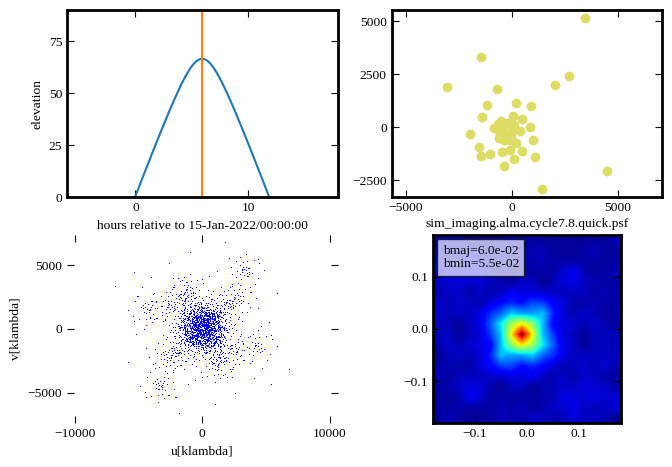

In [7]:
os.system('rm -rf sim_imaging/*')
simobserve(
    project            = 'sim_imaging',
    skymodel           = 'sky_gauss.fits', ###0埋めデータ/ノイズデータ？
    inbright           = "1Jy/pixel", ###0で装置のノイズのみになるはず？-->なってそうだけど観測時間100倍にしてもノイズ8倍くらいしか減らないのはなぜ？？
    indirection        = "J2000 09:00:45.833000 +00.41.23.20000", ###directionとの違いは？-->多分skymodelの一部を疑似観測する場合に使う。これはskymodelの座標を定める(ヘッダーを上書きする)。center of GOODS-ALMA。
    # indirection        = "J2000 00:00:00.000 +00.00.00.000", ###directionとの違いは？-->多分skymodelの一部を疑似観測する場合に使う。これはskymodelの座標を定める(ヘッダーを上書きする)。center of GOODS-ALMA。
    incell             = f"{pixsize_img}arcsec", ###ヘッダーを上書きするはず。
    incenter           = "270GHz", ###同じくskymodelのサブパラメータ
    inwidth            = "2GHz",
    setpointings       = True, ###If true (default), calculate a map of pointings and write ptgfile. If false, read pointings from ptgfile.
    integration        = "10s", ###defaultでは10s。多分1scanの積分時間（チョッピング周期かな？）。ポインティングごとに細かく変えたい時はptgファイルで上書きできる。
    direction          = "J2000 09:00:45.833000 +00.41.23.20000", ###実際に観測するMosaic center
    # direction          = "J2000 00:00:00.000 +00.00.00.000", ###directionとの違いは？-->多分skymodelの一部を疑似観測する場合に使う。これはskymodelの座標を定める(ヘッダーを上書きする)。center of GOODS-ALMA。
    # mapsize            = ["-2.8arcmin", "2.8arcmin"], ###空欄(default)だとskymodelに合わせる
    maptype            = "hexagonal", ###rasterもある
    pointingspacing    = "", ###空欄でALMAのdefaultに設定される(~0.51HPBW)
    obsmode		       = "int", ###interferometer mode
    antennalist        = './configuration_files/alma.cycle7.8.cfg' ,
    refdate            = "2022/1/15", ###Not critical unless concatting simulations
    hourangle          = "0h", ###「北中」する時(transitだと半分しかできない)
    totaltime          = "30s", # 72/4=18
    caldirection       = "",
    calflux            = "1Jy",
    thermalnoise       = "tsys-atm",
    user_pwv           = 0.1, ###かなり良い条件を仮定(default=0.5)
    t_ground           = 270.0, ###default=270
    seed               = 111,
    leakage            = 0.0, ###polarization leakage
    # graphics           = "none",
    verbose            = True,
    overwrite          = True
)

In [8]:
listobs(vis='sim_imaging/sim_imaging.alma.cycle7.8.noisy.ms', listfile='sim_imaging/listobs.txt', overwrite=True)
!cat sim_imaging/listobs.txt

           MeasurementSet Name:  /lwk/atsujita/HATLASJ0900/glint/examples/test_imaging/sim_imaging/sim_imaging.alma.cycle7.8.noisy.ms      MS Version 2
   Observer: CASA simulator     Project: sim_imaging.alma.cycle7.8  
Observation: ALMA
Data records: 2709       Total elapsed time = 30 seconds
   Observed from   15-Jan-2022/05:55:35.6   to   15-Jan-2022/05:56:05.6 (UTC)

   ObservationID = 0         ArrayID = 0
  Date        Timerange (UTC)          Scan  FldId FieldName             nRows     SpwIds   Average Interval(s)    ScanIntent
  15-Jan-2022/05:55:35.6 - 05:56:05.6     1      0 sim_imaging.alma.cy*      2709  [0]  [10] [OBSERVE_TARGET#ON_SOURCE]
           (nRows = Total number of rows per scan) 
Fields: 1
  ID   Code Name                RA               Decl           Epoch   SrcId      nRows
  0    OBJ  sim_imaging.alma.cy*09:00:45.833000 +00.41.23.20000 J2000   0           2709
Spectral Windows:  (1 unique spectral windows and 1 unique polarization setups)
  SpwID  Name   #C

### 位相中心から既知オフセットの点源を絶対座標で入れる。（u, vの向きを正確に把握するため）

In [9]:
# # model をクリア
# delmod(vis='sim_imaging/sim_imaging.alma.cycle7.8.noisy.ms', otf=True, scr=True)

# clttool = componentlist()
# clttool.addcomponent(
#     dir="J2000 00:00:00.000 +00.00.00.300",
#     flux=1.0, fluxunit='Jy',
#     shape='point'
# )
# clttool.rename('sim_imaging/ydir.cl')
# clttool.done()

# # ft
# ft(vis='sim_imaging/sim_imaging.alma.cycle7.8.noisy.ms', complist='sim_imaging/ydir.cl', usescratch=True)

### statwt

In [10]:
# statwt(vis='sim_imaging/sim_imaging.alma.cycle7.8.noisy.ms', datacolumn='data', fitspw='', combine='scan, corr', preview=False)

### CASA tclean

In [11]:
os.system("rm -r ./sim_imaging/casa_dirty*")
tclean(
    vis="./sim_imaging/sim_imaging.alma.cycle7.8.noisy.ms",
    imagename="./sim_imaging/casa_dirty",
    imsize=nx_img,
    cell="0.02arcsec",
    weighting="natural",
    niter=0,
    stokes="I",
    specmode="mfs",
    interactive=False,
)

exportfits(imagename='./sim_imaging/casa_dirty.image', fitsimage='./sim_imaging/casa_dirty.image.fits', overwrite=True)
exportfits(imagename='./sim_imaging/casa_dirty.psf', fitsimage='./sim_imaging/casa_dirty.psf.fits', overwrite=True)
exportfits(imagename='./sim_imaging/sim_imaging.alma.cycle7.8.skymodel', fitsimage='./sim_imaging/casa_dirty.skymodel.fits', overwrite=True)

rm: cannot remove './sim_imaging/casa_dirty*': No such file or directory
2026-07-20 15:08:32	WARN	task_tclean::SIImageStore::restore (file /source/casa6/casatools/src/code/synthesis/ImagerObjects/SIImageStore.cc, line 2284)	Restoring with an empty model image. Only residuals will be processed to form the output restored image.


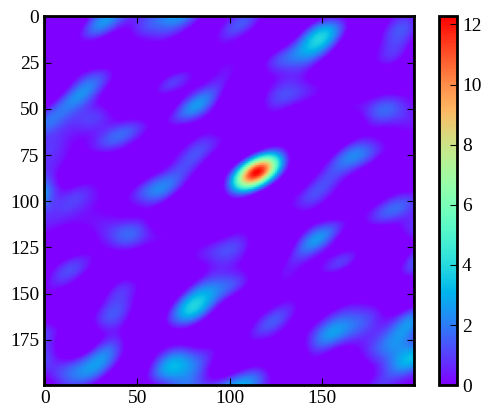

In [12]:
casa_image, casa_header = fits.getdata('./sim_imaging/casa_dirty.image.fits', header=True)
casa_image = np.squeeze(casa_image)

casa_beam = fits.getdata('./sim_imaging/casa_dirty.psf.fits')
casa_beam = np.squeeze(casa_beam)

plt.imshow(casa_image, cmap='rainbow', vmin=0)
plt.colorbar()
plt.show()

In [13]:
fits.getheader('./sim_imaging/casa_dirty.skymodel.fits')

SIMPLE  =                    T /Standard FITS                                   
BITPIX  =                  -32 /Floating point (32 bit)                         
NAXIS   =                    4                                                  
NAXIS1  =                  200                                                  
NAXIS2  =                  200                                                  
NAXIS3  =                    1                                                  
NAXIS4  =                    1                                                  
EXTEND  =                    T                                                  
BSCALE  =   1.000000000000E+00 /PHYSICAL = PIXEL*BSCALE + BZERO                 
BZERO   =   0.000000000000E+00                                                  
BTYPE   = 'Intensity'                                                           
OBJECT  = '        '                                                            
BUNIT   = 'Jy/pixel'        

In [14]:
casa_header

SIMPLE  =                    T /Standard FITS                                   
BITPIX  =                  -32 /Floating point (32 bit)                         
NAXIS   =                    4                                                  
NAXIS1  =                  200                                                  
NAXIS2  =                  200                                                  
NAXIS3  =                    1                                                  
NAXIS4  =                    1                                                  
EXTEND  =                    T                                                  
BSCALE  =   1.000000000000E+00 /PHYSICAL = PIXEL*BSCALE + BZERO                 
BZERO   =   0.000000000000E+00                                                  
BMAJ    =   1.665766040484E-05                                                  
BMIN    =   1.519587201377E-05                                                  
BPA     =   5.267468261719E+

In [15]:
# peak 座標
np.unravel_index(np.argmax(casa_image), casa_image.shape)

(np.int64(84), np.int64(115))

In [16]:
casa_header['CDELT2'] * 3600
crpix = casa_header['CRPIX1']
print(f"CRPIX: {crpix} / total pixels: {nx_img}")

CRPIX: 101.0 / total pixels: 200


### NUFFT

In [17]:
def getdata(ms):
    """
    注意：配列が同じshapeでないと全部取れない。channel数がspwによって違う場合は正しくない。
    そういう場合は getvarcol を使うこと。ここではどうせ全部平均するので問題ないが。
    """
    tb = table()
    tb.open(ms)
    obsid      = np.squeeze(tb.getcol("OBSERVATION_ID")) # EB
    uvw        = np.squeeze(tb.getcol("UVW"))
    ant1       = np.squeeze(tb.getcol("ANTENNA1"))
    ant2       = np.squeeze(tb.getcol("ANTENNA2"))
    data_pol   = np.squeeze(tb.getcol("CORRECTED_DATA"))
    sigma_pol  = np.squeeze(tb.getcol("SIGMA"))
    weight_pol = np.squeeze(tb.getcol("WEIGHT"))
    data_id    = np.squeeze(tb.getcol("DATA_DESC_ID")) # SPW
    time       = np.squeeze(tb.getcol("TIME"))
    scan       = np.squeeze(tb.getcol("SCAN_NUMBER"))
    flag       = np.squeeze(tb.getcol("FLAG"))
    tb.close()

    # phase center
    tb.open(ms + "/FIELD")
    phase_dir = np.squeeze(tb.getcol("PHASE_DIR"))
    tb.close()
    phase_dir = np.rad2deg(phase_dir)  # [rad] -> [deg]
    
    # print shapes
    print(f"Shape of obsid: {obsid.shape}")
    print(f"Shape of uvw: {uvw.shape}")
    print(f"Shape of ant1: {ant1.shape}")
    print(f"Shape of ant2: {ant2.shape}")
    print(f"Shape of data: {data_pol.shape}")
    print(f"Shape of sigma: {sigma_pol.shape}")
    print(f"Shape of weight: {weight_pol.shape}")
    print(f"Shape of data_id: {data_id.shape}")
    print(f"Shape of time: {time.shape}")
    print(f"Shape of scan: {scan.shape}")
    print(f"Shape of flag: {flag.shape}")
    print(f"phase center (deg): {phase_dir}")

    return obsid, uvw, ant1, ant2, data_pol, sigma_pol, weight_pol, data_id, time, scan, flag, phase_dir

In [18]:
simms = 'sim_imaging/sim_imaging.alma.cycle7.8.ms'
obsid, uvw, ant1, ant2, data_pol, sigma_pol, weight_pol, data_id, time, scan, flag, phase_dir = getdata(simms)

# flagデータの割合
print(f"Flagged data fraction: {np.sum(flag) / flag.size}")
flag = flag[0]

# Get the frequencies assoc. with each spw, since uvw coordinates are in m, not wavelengths
spw = '0'
tb = table()
tb.open(simms+'/SPECTRAL_WINDOW')
t1 = tb.selectrows([int(s) for s in spw.split(',')])
freqs = np.squeeze(t1.getcol('CHAN_FREQ')) # this column is the center freq of each channel===spw
t1.close(); tb.close()

print("Frequencies for each SPW (Hz):", freqs)

# Get the primary beam size
diam = 12.0  # ALMA antenna diameter in m
PBfwhm = (1.13 * (c / np.mean(freqs*u.Hz)) / (diam*u.m) * (3600*180/np.pi)).to("")

print(f"Primary beam FWHM (arcsec): {PBfwhm:.3f}")

# Current data+sigma has two pols, average them with weighted mean
data = np.average(data_pol, axis=0, weights=sigma_pol**-2) # テスト済み
sigma = np.sum((sigma_pol**-2.), axis=0)**-0.5
weight = np.sum(weight_pol, axis=0)

# Convert uvw coords from m to wavelengths
for i, spwid in enumerate(spw.split(',')):
    m = (data_id == int(spwid))
    uvw[:, m] /= c.to(u.m/u.s).value / freqs
print("Converted uvw to wavelengths.")

# phase center
tb.open(simms + "/FIELD")
phase_dir = np.squeeze(tb.getcol("PHASE_DIR"))
tb.close()
phase_dir = np.rad2deg(phase_dir)  # [rad] -> [deg]
print(f"phase center (deg): {phase_dir}")


Shape of obsid: (2709,)
Shape of uvw: (3, 2709)
Shape of ant1: (2709,)
Shape of ant2: (2709,)
Shape of data: (2, 2709)
Shape of sigma: (2, 2709)
Shape of weight: (2, 2709)
Shape of data_id: (2709,)
Shape of time: (2709,)
Shape of scan: (2709,)
Shape of flag: (2, 2709)
phase center (deg): [135.19097083   0.68977778]
Flagged data fraction: 0.0
Frequencies for each SPW (Hz): 269999999999.99997
Primary beam FWHM (arcsec): 21.566
Converted uvw to wavelengths.
phase center (deg): [135.19097083   0.68977778]


In [19]:
sys.path.append('/home/tsujtaak/atsujita/HATLASJ0900/kinematics/delens')
import fft_uv
import importlib
importlib.reload(fft_uv)
from fft_uv import vis_to_image_finufft_type3
import calc_lensing
importlib.reload(calc_lensing)
import calc_lensing as cl

In [20]:
x0_img, y0_img = 0.0, 0.0
xx_img, yy_img = cl.make_grid_arcsec(nx=nx_img, ny=ny_img, pixscale_arcsec=pixsize_img, x0_arcsec=x0_img, y0_arcsec=y0_img)

nufft_image, nufft_beam = vis_to_image_finufft_type3(
    u=uvw[0, :],
    v=uvw[1, :],
    V=data,
    V_weight=weight,
    xx_as=xx_img,
    yy_as=yy_img,
    eps=1e-6
)

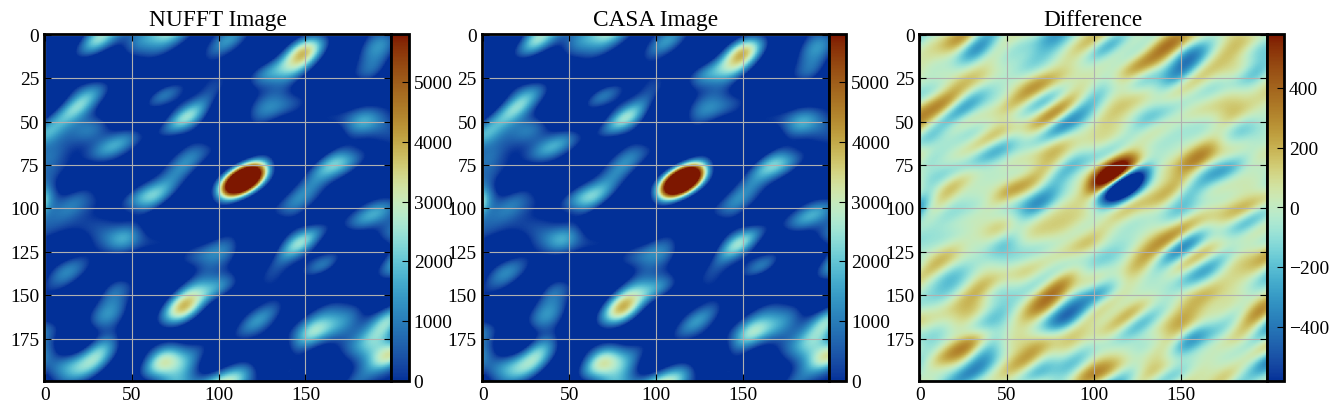

In [21]:
# compare with CASA image
vmax = np.percentile(nufft_image, 99.5)*1e3
f, ax = plt.subplots(1, 3, figsize=(16,5))
im0 = ax[0].imshow(nufft_image*1e3, cmap=cm.roma_r, vmin=0, vmax=vmax)
im1 = ax[1].imshow(casa_image*1e3, cmap=cm.roma_r, vmin=0, vmax=vmax)
im2 = ax[2].imshow(nufft_image*1e3 - casa_image*1e3, cmap=cm.roma_r, vmin=-0.1*vmax, vmax=0.1*vmax)

im = [im0, im1, im2]
titles = ['NUFFT Image', 'CASA Image', 'Difference']
for i in range(len(ax)):
    ax[i].set_title(titles[i])
    divider = make_axes_locatable(ax[i])
    cax = divider.append_axes("right", size="5%", pad=0)
    f.colorbar(im[i], cax=cax)
    ax[i].grid()


f.savefig('compare_nufft_casa_test3.pdf', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# import numpy as np

# # MS
# ra_ms_deg, dec_ms_deg = phase_dir
# dec0 = np.deg2rad(dec_ms_deg)

# # FITS
# ra_fits_deg  = obsheader['CRVAL1']
# dec_fits_deg = obsheader['CRVAL2']

# # 差分（deg）
# dra_deg  = ra_fits_deg  - ra_ms_deg
# ddec_deg = dec_fits_deg - dec_ms_deg

# # lm（rad）に変換（東向き l = +RA*cosδ、北向き m = +Dec）
# dl = np.deg2rad(dra_deg) * np.cos(dec0)
# dm = np.deg2rad(ddec_deg)

# print(f"ΔRA*cosδ = {np.rad2deg(dl)*3600:.3f} arcsec,  ΔDec = {np.rad2deg(dm)*3600:.3f} arcsec")

### 逆に image --> uv visibility が正しいかチェック

In [ ]:
from fft_uv import image_to_vis_finufft_type3

# CASA image to visibility
skymodel = fits.getdata('./sim_imaging/casa_dirty.skymodel.fits').astype(np.float32)
xx_rad, yy_rad = xx_img * (np.pi / 180.) / 3600., yy_img * (np.pi / 180.) / 3600.  # arcsec -> rad  
xx_rad = xx_rad.ravel().astype(np.float32)
yy_rad = yy_rad.ravel().astype(np.float32)
u = uvw[0, :]
v = uvw[1, :]
kx = (2.0 * np.pi * u).astype(np.float32)
ky = (2.0 * np.pi * v).astype(np.float32)
im2vis = image_to_vis_finufft_type3(
    I=skymodel, 
    xx_as=xx_rad,
    yy_as=yy_rad,
    kx=kx,
    ky=ky,
    )

In [ ]:
data = np.average(data_pol, axis=0, weights=sigma_pol**-2) # テスト済み
sigma = np.sum((sigma_pol**-2.), axis=0)**-0.5
weight = np.sum(weight_pol, axis=0)


obs_amp = np.abs(data)
mod_amp = np.abs(im2vis)
res_amp = (obs_amp - mod_amp) / 1

vmin, vmax = np.percentile(obs_amp, [5, 95])

f, ax = plt.subplots(1,3, figsize=(14,4))
im0 = ax[0].scatter(uvw[0], uvw[1], c=obs_amp, s=1, vmin=vmin, vmax=vmax)
im1 = ax[1].scatter(uvw[0], uvw[1], c=mod_amp, s=1, vmin=vmin, vmax=vmax)
im2 = ax[2].scatter(uvw[0], uvw[1], c=res_amp, s=1, vmin=-0.1*vmax, vmax=0.1*vmax)

# colorbarをつける
im = [im0, im1, im2]
titles = ["Observed visibilities", "Model visibilities", "Residual (sigma units)"]
for i in range(3):
    ax[i].set_title(titles[i])
    divider = make_axes_locatable(ax[i])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    f.colorbar(im[i], cax=cax, orientation='vertical')
    ax[i].set_xlabel(r"$u$  /$\lambda$")
    ax[i].set_ylabel(r"$v$  /$\lambda$")


plt.tight_layout()
plt.show()

## Test 0

In [ ]:
data = np.average(data_pol, axis=0, weights=sigma_pol**-2) # テスト済み

def wrap_to_pi(x): return (x + np.pi) % (2*np.pi) - np.pi

pointsrc_arg_obs = np.angle(data)  # angleは(-pi, +pi]
pointsrc_arg_true = -2 * np.pi * (uvw[0, :] * np.deg2rad(x0/3600) + uvw[1, :] * np.deg2rad(y0/3600))  # rad
pointsrc_arg_true = wrap_to_pi(pointsrc_arg_true)
pointsrc_arg_res = pointsrc_arg_obs - pointsrc_arg_true

# pointsrc_arg_obs = data.real
# pointsrc_arg_true = np.cos(-2 * np.pi * (uvw[0, :] * np.deg2rad(x0/3600) + uvw[1, :] * np.deg2rad(y0/3600)))  # rad
# vmin, vmax = np.percentile(obs_amp, [5, 95])

f, ax = plt.subplots(1,3, figsize=(14,4))
im0 = ax[0].scatter(uvw[0], uvw[1], c=pointsrc_arg_obs, s=1)
im1 = ax[1].scatter(uvw[0], uvw[1], c=pointsrc_arg_true, s=1)
im2 = ax[2].scatter(uvw[0], uvw[1], c=pointsrc_arg_res, s=1)

# colorbarをつける
im = [im0, im1, im2]
titles = ["Observed phases", "True phases", "Residual phases"]
for i in range(3):
    ax[i].set_title(titles[i])
    divider = make_axes_locatable(ax[i])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    f.colorbar(im[i], cax=cax, orientation='vertical')
    ax[i].set_xlabel(r"$u$  /$\lambda$")
    ax[i].set_ylabel(r"$v$  /$\lambda$")
    # ax[i].set_xlim(0, 2e6)
    # ax[i].set_ylim(0, 2e6)

plt.tight_layout()
plt.show()

In [ ]:
# u=0の断面にそってobserved phaseをプロット

u0_tol = 1e4
mask_u0 = np.abs(uvw[0, :]) < u0_tol
u_u0 = uvw[0, mask_u0]
v_u0 = uvw[1, mask_u0]
pointsrc_arg_obs_u0 = pointsrc_arg_obs[mask_u0]

pointsrc_arg_true_u0 = -2 * np.pi * (u_u0 * np.deg2rad(x0/3600) + v_u0 * np.deg2rad(y0/3600))  # rad

In [ ]:
f, ax = plt.subplots(1,1, figsize=(6,5))
ax.scatter(v_u0, pointsrc_arg_obs_u0, s=1)
plt.show()